In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df = pd.read_csv(r"C:\Users\A2B\Downloads\marketing_campaign_data.csv")

# 2. Check basic structure
print("--- Dataset Shape ---")
print(df.shape)



--- Dataset Shape ---
(56000, 28)


In [7]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,342199,1985,Graduation,Together,59011.7,1,0,2012-11-17,3,0,...,3,4,0,0,0,0,0,0,0,Spain
1,8075450,1975,Master,Single,1730.0,1,1,2013-04-10,96,0,...,2,3,0,0,0,0,0,0,0,Spain
2,13664263,1978,Graduation,Married,98584.6,0,0,2014-01-11,99,920,...,6,3,0,0,0,0,0,0,0,Australia
3,16164787,1976,Graduation,Married,74031.5,1,0,2014-06-18,47,265,...,11,4,0,0,0,0,0,0,0,Spain
4,15815139,1981,Graduation,Divorced,52784.2,1,1,2014-05-20,0,30,...,3,6,0,0,0,0,0,0,0,Canada


In [8]:
print("\n--- Data Types & Missing Values ---")
print(df.info())


--- Data Types & Missing Values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56000 entries, 0 to 55999
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   56000 non-null  int64  
 1   Year_Birth           56000 non-null  int64  
 2   Education            56000 non-null  object 
 3   Marital_Status       56000 non-null  object 
 4   Income               56000 non-null  float64
 5   Kidhome              56000 non-null  int64  
 6   Teenhome             56000 non-null  int64  
 7   Dt_Customer          56000 non-null  object 
 8   Recency              56000 non-null  int64  
 9   MntWines             56000 non-null  int64  
 10  MntFruits            56000 non-null  int64  
 11  MntMeatProducts      56000 non-null  int64  
 12  MntFishProducts      56000 non-null  int64  
 13  MntSweetProducts     56000 non-null  int64  
 14  MntGoldProds         56000 non-null  int64  
 15 

In [9]:
print("\n--- Missing Values Count ---")
print(df.isnull().sum())


--- Missing Values Count ---
ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Response               0
Complain               0
Country                0
dtype: int64


**Minimum preprocessing expectations**:
Convert Dt_Customer to date type and derive Customer_Tenure (e.g., in days or months from reference date).
Create derived metrics:
Age from Year_Birth.
Total_Spend as sum of all Mnt* fields.
Total_Purchases as sum of channel purchases.
Children = Kidhome + Teenhome.
Handle outliers and missing values in numeric fields (e.g., unrealistic ages, income).


In [11]:
# Date conversion & Tenure calculation
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])
# Using Reference date as  project timeline standard dynamic
df['Customer_Tenure_Days'] = (pd.to_datetime('2026-07-03') - df['Dt_Customer']).dt.days

# Creating derived metrics as per guidelines
df['Age'] = 2026 - df['Year_Birth']

df['Total_Spend'] = df[['MntWines', 'MntFruits', 'MntMeatProducts', 
                        'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum(axis=1)

df['Total_Purchases'] = df[['NumWebPurchases', 'NumCatalogPurchases', 
                            'NumStorePurchases']].sum(axis=1)

df['Children'] = df['Kidhome'] + df['Teenhome']

print(df[['Age', 'Total_Spend', 'Total_Purchases', 'Children']].head())

   Age  Total_Spend  Total_Purchases  Children
0   41           69               10         1
1   51           39                3         2
2   48         1512                9         0
3   50          478               15         1
4   45          330                8         2


Outlier Handling (Age & Income)
Identify and handle extreme unrealistic ages,income columns with basic boxplot logic 

In [12]:
# Unrealistic age filters (e.g., age > 100)
df = df[df['Age'] < 100]

# Fill Income column missing values with Median 
df['Income'] = df['Income'].fillna(df['Income'].median())

# To Clean Unrealistic High Income values capping to (99th percentile or standard rule)
income_cap = df['Income'].quantile(0.99)
df = df[df['Income'] <= income_cap]

In [13]:
print("--- Missing Values After Cleaning ---")
print(df[['Income', 'Age']].isnull().sum())

--- Missing Values After Cleaning ---
Income    0
Age       0
dtype: int64


In [16]:
# DATA CLEANING VERIFICATION: Summary Statistics after Outlier Removal & Capping
# Purpose: Check the minimum and maximum ranges of Age and Income to verify cleaning.
# Using round() and astype(int) to remove floating decimals for cleaner presentation.

print("--- Clean Summary Statistics ---")
print(df[['Age', 'Income']].describe().round(0).astype(int))

--- Clean Summary Statistics ---
         Age  Income
count  55440   55440
mean      54   56642
std       12   33901
min       30    1730
25%       45   27898
50%       53   58299
75%       63   86020
max       90  113819


**Key Observations & Verification**:

| Statistic |    Age |  Income | Meaning                                                                                                                                                                               
| **count** | 55,440 |  55,440 | There are **55,440 records**, and no missing values remain in these columns.                                                                                                          |
| **mean**  |     54 |  56,642 | The average age is **54 years**, and the average income is **56,642**.                                                                                                                |
| **std**   |     12 |  33,901 | Standard deviation shows how spread out the values are. Age varies by about **12 years** from the average, and income varies by about **33,901**, indicating a wide range of incomes. |
| **min**   |     30 |   1,730 | The youngest customer is **30 years old**, and the lowest income is **1,730**.                                                                                                        |
| **25%**   |     45 |  27,898 | **25% of customers** are **45 years or younger**, and **25%** have an income of **27,898 or less**. This is the **first quartile (Q1)**.                                              |
| **50%**   |     53 |  58,299 | This is the **median**. Half the customers are **53 years or younger**, and half earn **58,299 or less**.                                                                             |
| **75%**   |     63 |  86,020 | **75% of customers** are **63 years or younger**, and **75%** earn **86,020 or less**. This is the **third quartile (Q3)**.                                                           |
| **max**   |     90 | 113,819 | The oldest customer is **90 years**, and the highest income is **113,819**.                                                                                                           |


**APPROACH 2**
**Exploratory Data Analysis** (Python)
**Perform univariate analysis**: distributions of age, income, spending, recency, etc.
**Perform bivariate/multivariate analysis**: response vs. income, response vs. age, response vs. product spend, channel usage vs. response, etc.
Identify key patterns and segments.


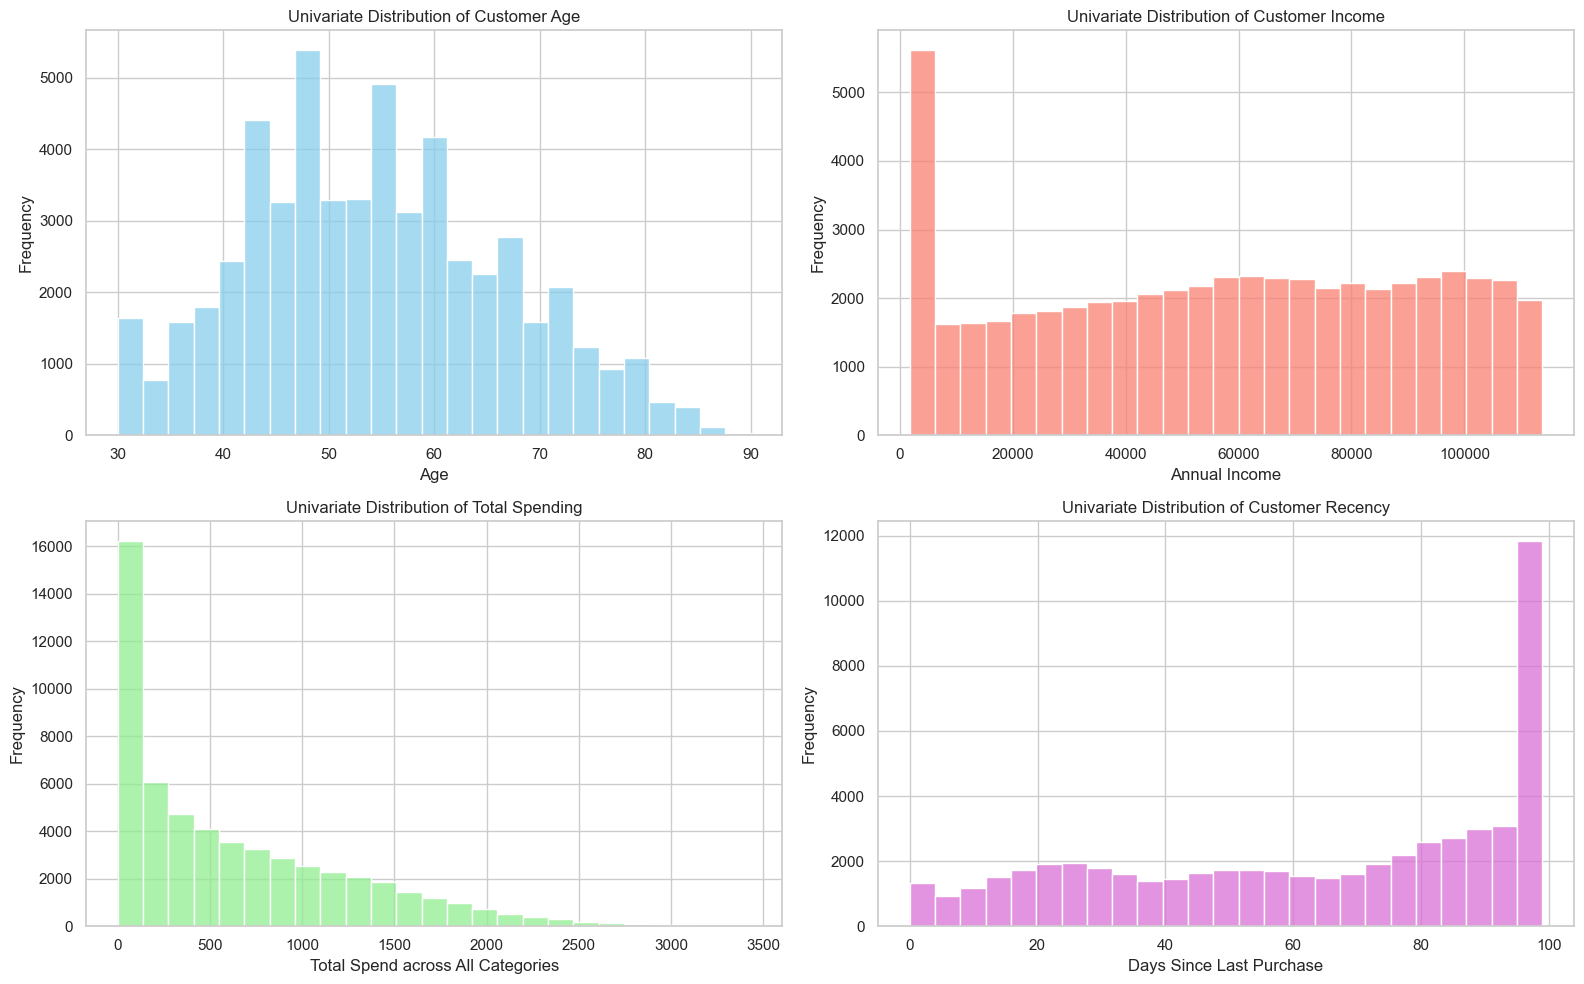

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set global plotting parameters for consistency
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 10))

# 1. Distribution of Age 
plt.subplot(2, 2, 1)
sns.histplot(data=df, x='Age', kde=False, color='skyblue', bins=25)
plt.title('Univariate Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

# 2. Distribution of Income 
plt.subplot(2, 2, 2)
sns.histplot(data=df, x='Income', kde=False, color='salmon', bins=25)
plt.title('Univariate Distribution of Customer Income')
plt.xlabel('Annual Income')
plt.ylabel('Frequency')

# 3. Distribution of Total Spending (Removed KDE line)
plt.subplot(2, 2, 3)
sns.histplot(data=df, x='Total_Spend', kde=False, color='lightgreen', bins=25)
plt.title('Univariate Distribution of Total Spending')
plt.xlabel('Total Spend across All Categories')
plt.ylabel('Frequency')

# 4. Distribution of Recency (Removed KDE line)
plt.subplot(2, 2, 4)
sns.histplot(data=df, x='Recency', kde=False, color='orchid', bins=25)
plt.title('Univariate Distribution of Customer Recency')
plt.xlabel('Days Since Last Purchase')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### **Univariate Analysis Insights**
**Key Observations:**
1. Age Distribution 
Observations: Most customers are middle-aged.
The highest concentration of customers is between 45 and 60 years.
The peak appears to be around 48–55 years.
*Insight*: The business mainly serves middle-aged customers,Younger customers form a smaller part of the customer base.
After about 75 years, the number of customers decreases sharply,Ages are within a reasonable range (30–90).

2. Income Distribution 
Observations:The first bar is much taller than the others.Many customers have very low incomes.Missing values may have been filled with a small value  or The dataset genuinely may contain many low-income customers.Income ranges from approximately ₹1,700 to ₹113,819 and even after that.The graph ends around ₹113,819-outlier capping at the 99th percentile was effective.


3.Total Spending Distribution
Observations:Most customers have low total spending,The tallest bar is close to ₹0–₹200,Very few customers spend above ₹2,500–₹3,000.

4.Customer Recency Distribution
Observations:The bars near 0–10 days are much shorter-here are relatively fewer customers who purchased very recently.As recency increases, the number of customers generally increases.100 is the maximum recorded recency in the dataset.Many customers have not purchased for the longest recorded period.


**Section 2: Bivariate & Multivariate Analysis**

Objective: Evaluate how demographics shift by campaign acceptance (Response), track behavior patterns across product categories (Product Spend), and discover where converters shop (Channel Usage).

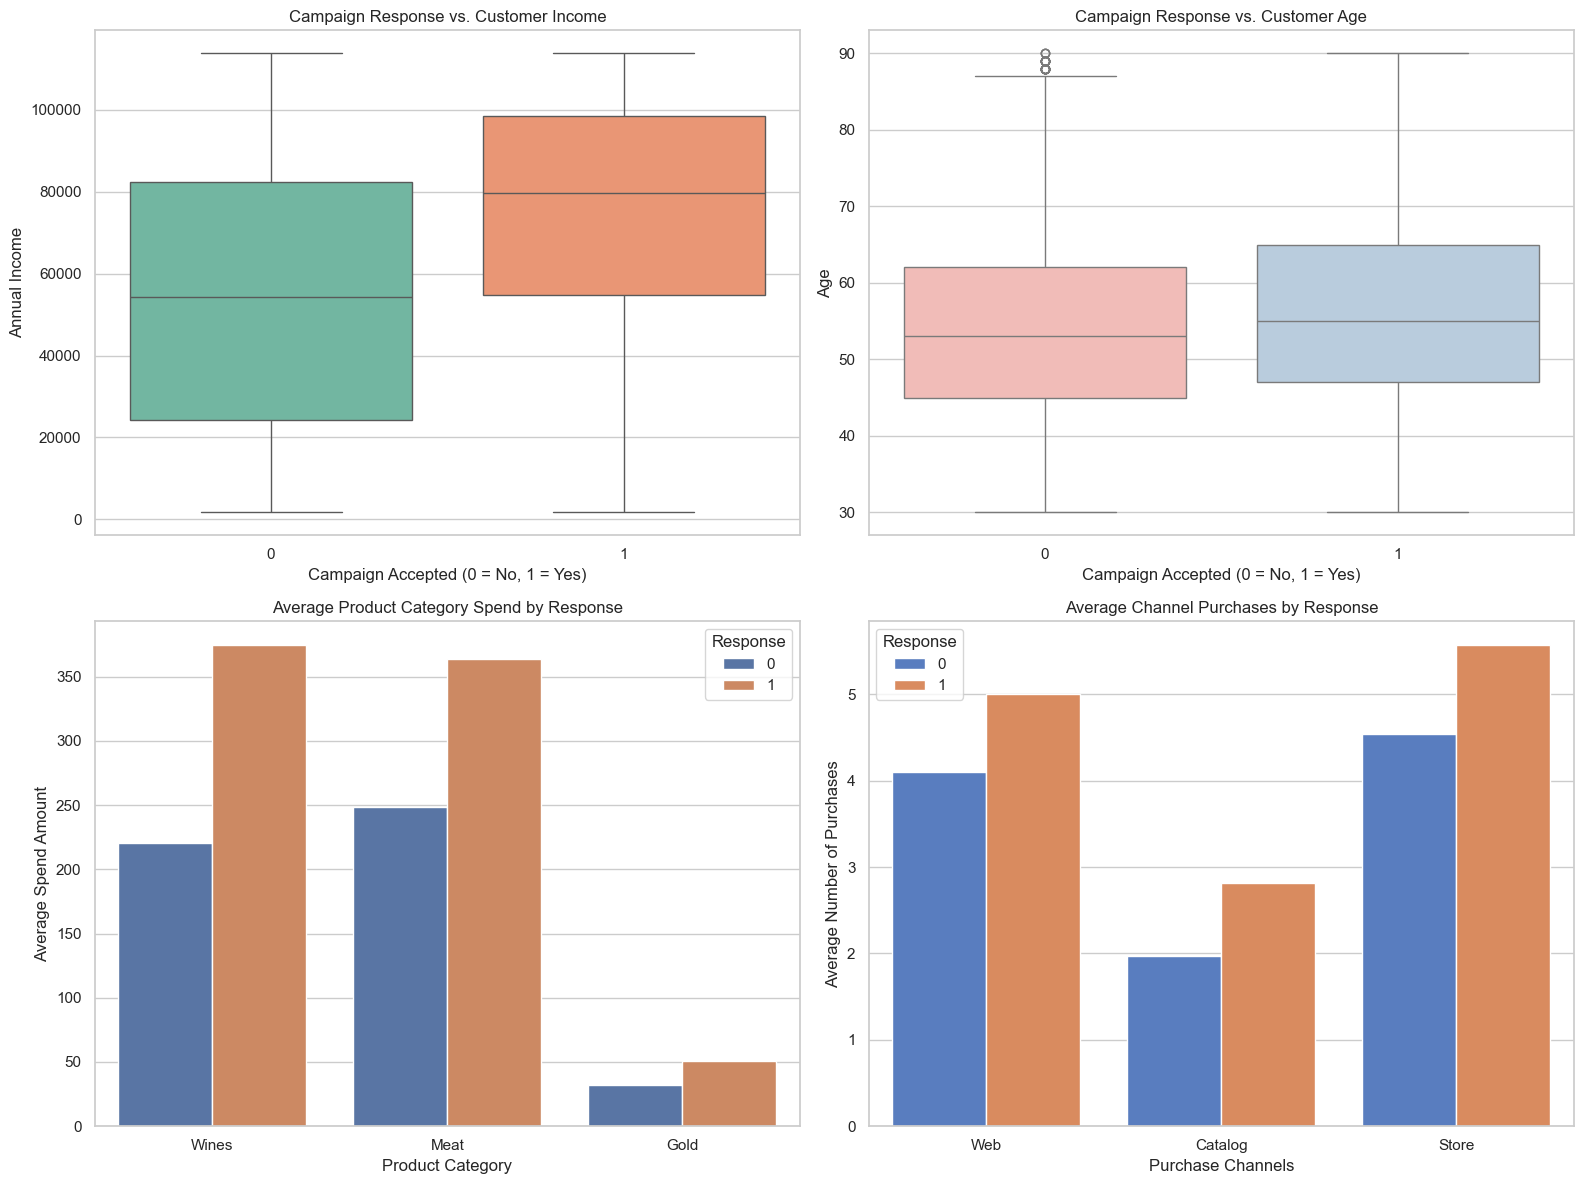

In [26]:
# Create a multi-plot layout for detailed Bivariate Exploratory Visualizations
plt.figure(figsize=(16, 12))

# Plot 1: Campaign Response vs. Customer Income (Using hue to avoid warnings)
plt.subplot(2, 2, 1)
sns.boxplot(data=df, x='Response', y='Income', hue='Response', palette='Set2', legend=False)
plt.title('Campaign Response vs. Customer Income')
plt.xlabel('Campaign Accepted (0 = No, 1 = Yes)')
plt.ylabel('Annual Income')

# Plot 2: Campaign Response vs. Customer Age
plt.subplot(2, 2, 2)
sns.boxplot(data=df, x='Response', y='Age', hue='Response', palette='Pastel1', legend=False)
plt.title('Campaign Response vs. Customer Age')
plt.xlabel('Campaign Accepted (0 = No, 1 = Yes)')
plt.ylabel('Age')

# Plot 3: Response vs. Average Product Spend (Comparing Wines and Meat Products)
product_cols = ['MntWines', 'MntMeatProducts', 'MntGoldProds']
df_products = df.melt(id_vars=['Response'], value_vars=product_cols, var_name='Product', value_name='Spend')

plt.subplot(2, 2, 3)
sns.barplot(data=df_products, x='Product', y='Spend', hue='Response', palette='deep', errorbar=None)
plt.title('Average Product Category Spend by Response')
plt.xlabel('Product Category')
plt.ylabel('Average Spend Amount')
plt.xticks(ticks=[0, 1, 2], labels=['Wines', 'Meat', 'Gold'])

# Plot 4: Channel Usage vs. Campaign Response
channel_cols = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
df_channels = df.melt(id_vars=['Response'], value_vars=channel_cols, var_name='Channel', value_name='Purchases')

plt.subplot(2, 2, 4)
sns.barplot(data=df_channels, x='Channel', y='Purchases', hue='Response', palette='muted', errorbar=None)
plt.title('Average Channel Purchases by Response')
plt.xlabel('Purchase Channels')
plt.ylabel('Average Number of Purchases')
plt.xticks(ticks=[0, 1, 2], labels=['Web', 'Catalog', 'Store'])

plt.tight_layout()
plt.show()

### **Bivariate & Multivariate Analysis Insights**

**Key Observations:**
Campaign Response vs. Income
Observation : Campaign responders have higher incomes
The median income for customers who accepted the campaign (1) is much higher than for those who did not accept (0).
Campaign Response vs. Age
Observation : Customers of many different ages both accepted and rejected the campaign.
Average Product Category Spend by Response:
Observation :Customers who accepted the campaign spend more across all product categories.The gap between responders and non-responders is largest for Wines.
Average Channel Purchases by Response
Observation :Store purchases are highest.Catalog purchases are the lowest.Customers who are more active shoppers are more likely to respond positively to campaigns.


APPROACH 3
***Rule based segmentation task***

| Segment Name | Rule Definition | Example Value(s) |
|---------------|-----------------|------------------|
| High Income | Income > ₹75,000 | 75001–99999 |
| Young Customer | Age < 30 | 18–29 |
| Campaign Responder | Response = 1 | 1 |
| High Web Engagement | NumWebVisitsMonth > 5 | 6–20 |
| Family Customer | Children > 0 | 1–3 |
| High Spender | Total_Spend > 90th percentile | > ₹50,000 |

In [18]:
# ===================================================================================================
# RULE-BASED CUSTOMER SEGMENTATION 
# Purpose: Define and apply business rules to flag different customer segments.(Feature Engineering)
# ===================================================================================================

# 1. High Income: Income > 75,000
df['Segment_High_Income'] = np.where(df['Income'] > 75000, 1, 0)

# 2. Young Customer: Age < 30
df['Segment_Young_Customer'] = np.where(df['Age'] < 30, 1, 0)

# 3. Campaign Responder: Response == 1
df['Segment_Campaign_Responder'] = np.where(df['Response'] == 1, 1, 0)

# 4. High Web Engagement: NumWebVisitsMonth > 5
df['Segment_High_Web_Engagement'] = np.where(df['NumWebVisitsMonth'] > 5, 1, 0)

# 5. Family Customer: Children > 0 (Kidhome + Teenhome)
df['Segment_Family_Customer'] = np.where(df['Children'] > 0, 1, 0)

# 6. High Spender: Total_Spend >= 90th Percentile
spend_90th = df['Total_Spend'].quantile(0.90)
df['Segment_High_Spender'] = np.where(df['Total_Spend'] >= spend_90th, 1, 0)

# Summary of Segment Distributions
segment_columns = [
    'Segment_High_Income', 'Segment_Young_Customer', 'Segment_Campaign_Responder',
    'Segment_High_Web_Engagement', 'Segment_Family_Customer', 'Segment_High_Spender'
]

print("--- Total Customers in Each Segment ---")
print(df[segment_columns].sum())

--- Total Customers in Each Segment ---
Segment_High_Income            19222
Segment_Young_Customer             0
Segment_Campaign_Responder      8081
Segment_High_Web_Engagement    29839
Segment_Family_Customer        38049
Segment_High_Spender            5546
dtype: int64


**Rule-Based Customer Segmentation Analysis**

**Objective:** To isolate specific target groups based on business demographic and behavioral constraints to evaluate marketing responsiveness.

**Key Metrics to be Captured:**

**High Income & High Spenders:** Identifies premium audience clusters driving top-line revenue metrics.

**Family vs. Young Customer Demographics:** Benchmarks customer composition to customize regional or campaign-level distribution.

**Engagement Triggers:** Tracks active web users (`High Web Engagement`) and historic conversions (`Campaign Responder`) to construct ideal target profiling.

In [27]:
import pandas as pd
import numpy as np

# ==============================================================================
# STEP 3.1: PYTHON RULE-BASED SEGMENTATION LAYER
# Purpose: Apply precise business rule logic to categorize profiles into segments
# ==============================================================================

# Calculate dynamic 90th percentile threshold for High Spender evaluation
spend_90th_threshold = df['Total_Spend'].quantile(0.90)

# Apply explicit segment mapping using vector business rules
df['Is_High_Income'] = np.where(df['Income'] > 75000, 'Yes', 'No')
df['Is_Young_Customer'] = np.where(df['Age'] < 30, 'Yes', 'No')
df['Is_Campaign_Responder'] = np.where(df['Response'] == 1, 'Yes', 'No')
df['Is_High_Web_Engaged'] = np.where(df['NumWebVisitsMonth'] > 5, 'Yes', 'No')
df['Is_Family_Customer'] = np.where(df['Children'] > 0, 'Yes', 'No')
df['Is_High_Spender'] = np.where(df['Total_Spend'] >= spend_90th_threshold, 'Yes', 'No')

# Create a consolidated master segment string for direct dashboard categorizations
conditions = [
    (df['Total_Spend'] >= spend_90th_threshold),
    (df['Income'] > 75000),
    (df['Children'] > 0)
]
choices = ['High Spender', 'High Income Elite', 'Family Shopper']
df['Primary_Market_Segment'] = np.select(conditions, choices, default='Standard Retail Profile')

# Display shape verification and structural preview
print("--- Post-Segmentation Dimensions ---")
print(df.shape)
print("\n--- Consolidated Segment Profile Sample ---")
print(df[['Age', 'Income', 'Total_Spend', 'Primary_Market_Segment']].head(5))

--- Post-Segmentation Dimensions ---
(55440, 46)

--- Consolidated Segment Profile Sample ---
   Age   Income  Total_Spend Primary_Market_Segment
0   41  59011.7           69         Family Shopper
1   51   1730.0           39         Family Shopper
2   48  98584.6         1512      High Income Elite
3   50  74031.5          478         Family Shopper
4   45  52784.2          330         Family Shopper


In [28]:
!pip install psycopg2-binary sqlalchemy

Defaulting to user installation because normal site-packages is not writeable


In [33]:
import pandas as pd
from sqlalchemy import create_engine
from urllib.parse import quote_plus  # <-- Added this to handle the special character

# Database configuration parameters
DB_USER = 'postgres'
DB_PASSWORD = 'Post@2026' 
DB_HOST = 'localhost'
DB_PORT = '5432'
DB_NAME = 'postgres'                  

# Cleanly encode the password string containing '@'
safe_password = quote_plus(DB_PASSWORD)

# Build the connection string using the safely encoded password
conn_str = f'postgresql://{DB_USER}:{safe_password}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
engine = create_engine(conn_str)

# Upload the DataFrame to PostgreSQL
try:
    df.to_sql(name='marketing_camp_data_table', con=engine, if_exists='replace', index=False)
    print(" Success! Your dataframe is uploaded into PostgreSQL as 'marketing_camp_data_table'.")
except Exception as e:
    print(f"❌ Error uploading: {e}")

 Success! Your dataframe is uploaded into PostgreSQL as 'marketing_camp_data_table'.
